## PubMedBert(Axis 1) + MLP(Axis 2)

In [1]:
!pip install python-dotenv

In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from pubmed_loader import PubMedQAData
from pubmedbert_preprocess import pubmedbert_preprocess

In [3]:
RANDOM_SEED = 11
MODEL_NAME  = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
DEVICE      = torch.device("xpu" if torch.xpu.is_available() else
               "cuda" if torch.cuda.is_available() else "cpu")

LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

set_all_seeds()
print(f"Using device: {DEVICE}")

All seeds set to 11
Using device: cpu


### 1. Data loading

In [4]:
data = PubMedQAData("data")

# Variant A — plain question + context
train_enc_a, train_labels = pubmedbert_preprocess(data.train_set, tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
dev_enc_a,   dev_labels   = pubmedbert_preprocess(data.dev_set,   tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
test_enc_a,  test_labels  = pubmedbert_preprocess(data.test_set,  tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)

# Variant B — question + context + MeSH terms appended
tokenizer_b = AutoTokenizer.from_pretrained(MODEL_NAME)
train_enc_b, _            = pubmedbert_preprocess(data.train_set, tokenizer=tokenizer_b, use_mesh=True)
dev_enc_b,   _            = pubmedbert_preprocess(data.dev_set,   tokenizer=tokenizer_b, use_mesh=True)
test_enc_b,  _            = pubmedbert_preprocess(data.test_set,  tokenizer=tokenizer_b, use_mesh=True)

print(f"train: {len(train_labels)} | dev: {len(dev_labels)} | test: {len(test_labels)}")
print("Train label dist:", np.bincount(train_labels.numpy()))
print("Dev   label dist:", np.bincount(dev_labels.numpy()))
print("Test  label dist:", np.bincount(test_labels.numpy()))

train: 450 | dev: 50 | test: 500
Train label dist: [249 152  49]
Dev   label dist: [27 17  6]
Test  label dist: [276 169  55]


### 2. Pre-compute `[CLS]` Embeddings
Because BERT is fully frozen, we run it **once** over every split and cache the `[CLS]` vectors.
All MLP training then operates on plain `(N, 768)` float tensors, no BERT forward pass per epoch.

In [5]:
def extract_cls_embeddings(encodings, model, device, batch_size=32):
    """
    Run frozen BERT once and return (N, 768) [CLS] embeddings.
    """
    model.eval()
    all_cls = []
    n = encodings["input_ids"].size(0)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end       = min(start + batch_size, n)
            input_ids = encodings["input_ids"][start:end].to(device)
            attn_mask = encodings["attention_mask"][start:end].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            cls_vec   = outputs.last_hidden_state[:, 0, :].cpu()
            all_cls.append(cls_vec)

    return torch.cat(all_cls, dim=0)   # (N, 768)


bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
for p in bert_model.parameters():
    p.requires_grad = False
print("BERT loaded and frozen.")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

C:\Users\User\miniconda3\envs\text_analytics\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--microsoft--BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.


In [6]:
# ── Variant A ──────────────────────────────────────────────────────────────
print("Extracting Variant A embeddings (plain)...")
train_emb_a = extract_cls_embeddings(train_enc_a, bert_model, DEVICE)
dev_emb_a   = extract_cls_embeddings(dev_enc_a,   bert_model, DEVICE)
test_emb_a  = extract_cls_embeddings(test_enc_a,  bert_model, DEVICE)
print(f"  train {train_emb_a.shape} | dev {dev_emb_a.shape} | test {test_emb_a.shape}")

# ── Variant B ──────────────────────────────────────────────────────────────
print("Extracting Variant B embeddings (+ MeSH)...")
train_emb_b = extract_cls_embeddings(train_enc_b, bert_model, DEVICE)
dev_emb_b   = extract_cls_embeddings(dev_enc_b,   bert_model, DEVICE)
test_emb_b  = extract_cls_embeddings(test_enc_b,  bert_model, DEVICE)
print(f"  train {train_emb_b.shape} | dev {dev_emb_b.shape} | test {test_emb_b.shape}")

print("\nDone. BERT will not run again during MLP training.")

Extracting Variant A embeddings (plain)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])
Extracting Variant B embeddings (+ MeSH)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])

Done. BERT will not run again during MLP training.


### 3. DataLoaders

In [7]:
BATCH_SIZE = 64

def make_loaders(train_emb, dev_emb, test_emb,
                 train_labels, dev_labels, test_labels,
                 batch_size=BATCH_SIZE):
    train_ds     = TensorDataset(train_emb, train_labels)
    dev_ds       = TensorDataset(dev_emb,   dev_labels)
    test_ds      = TensorDataset(test_emb,  test_labels)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    return train_loader, dev_loader, test_loader

train_loader_a, dev_loader_a, test_loader_a = make_loaders(
    train_emb_a, dev_emb_a, test_emb_a,
    train_labels, dev_labels, test_labels
)
train_loader_b, dev_loader_b, test_loader_b = make_loaders(
    train_emb_b, dev_emb_b, test_emb_b,
    train_labels, dev_labels, test_labels
)
print("DataLoaders ready.")

DataLoaders ready.


### 4. MLP Architecture

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.projection = nn.Linear(768, input_dim)
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.projection(x)
        return self.network(x)

### 5. Training & Helper Functions

In [9]:
def train_MLP(num_epochs, model, train_loader, dev_loader,
              learning_rate, class_weights=None):
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(next(model.parameters()).device)
        )
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses = []
    all_dev_losses   = []
    best_dev_loss    = float('inf')
    best_state       = None

    for e in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────────
        model.train()
        train_losses  = []
        total_correct = 0
        total_trained = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            output     = model(batch_X)
            batch_loss = loss_fn(output, batch_y)
            batch_loss.backward()
            optimizer.step()

            train_losses.append(batch_loss.item())
            total_correct += (output.argmax(1) == batch_y).sum().item()
            total_trained += batch_y.size(0)

        train_acc = total_correct / total_trained * 100
        all_train_losses.append(np.mean(train_losses))
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_acc))

        # ── Validation ──────────────────────────────────────────────────────
        model.eval()
        dev_losses    = []
        total_correct = 0
        total_trained = 0

        with torch.no_grad():
            for dev_X, dev_y in dev_loader:
                dev_X, dev_y = dev_X.to(DEVICE), dev_y.to(DEVICE)
                dev_output   = model(dev_X)
                dev_loss     = loss_fn(dev_output, dev_y)
                dev_losses.append(dev_loss.item())
                total_correct += (dev_output.argmax(1) == dev_y).sum().item()
                total_trained += dev_y.size(0)

        dev_acc       = total_correct / total_trained * 100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(mean_dev_loss)
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Validation Loss: {:.4f}".format(mean_dev_loss),
              "Validation Accuracy: {:.4f}%".format(dev_acc))

        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

In [10]:
# ── Shared utility functions ────────────────────────────────────────────────

def training_curves(train_losses, dev_losses, title="Training curves"):
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(dev_losses,   label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    #plt.tight_layout()
    plt.show()


def predict(model, loader):
    model.eval()
    gold_labs, pred_labs = [], []
    with torch.no_grad():
        for X, y in loader:
            X                = X.to(DEVICE)
            predicted_labels = model(X).argmax(1)
            gold_labs.extend(y.tolist())
            pred_labs.extend(predicted_labels.cpu().tolist())
    return gold_labs, pred_labs


def evaluate(y_pred, y_true, split_name):
    """Print accuracy, per-class precision, recall, F1 and macro averages."""
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro")
    pre_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n── {split_name} ──")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro-F1       : {f1_macro:.4f}")
    print(f"Macro-Precision: {pre_macro:.4f}")
    print("\nFull Classification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["yes", "no", "maybe"],
        zero_division=0
    ))
    return acc, f1_macro, pre_macro


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.show()

---
### Axis 1 - Text Representation

| | Input to BERT |
|---|---|
| **Variant A** | `[question] + [context]` (plain baseline) |
| **Variant B** | `[question] + [context] + MeSH terms` (enriched) |

**Hypothesis:** MeSH terms are controlled biomedical vocabulary.  By adding them, the `[CLS]` embedding for domain-specific topics may be improved, particularly for the minority `maybe` class. However, MeSH terms appear at the end of the 512-token window so if a context is already long they may get truncated. This is a crucial failure scenario to look for in error analysis.

---
### Variant A - Plain question + context

In [11]:
set_all_seeds()

num_epochs    = 15
learning_rate = 5e-4

model_a = MLP(input_dim=128).to(DEVICE)
trained_model_a, train_losses_a, dev_losses_a = train_MLP(
    num_epochs, model_a, train_loader_a, dev_loader_a, learning_rate
)

All seeds set to 11
Epoch: 1/15 Training Loss: 1.0447 Training Accuracy: 49.7778%
Epoch: 1/15 Validation Loss: 0.9739 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9739)
Epoch: 2/15 Training Loss: 0.9379 Training Accuracy: 55.3333%
Epoch: 2/15 Validation Loss: 0.9469 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9469)
Epoch: 3/15 Training Loss: 0.8848 Training Accuracy: 55.3333%
Epoch: 3/15 Validation Loss: 0.9534 Validation Accuracy: 54.0000%
Epoch: 4/15 Training Loss: 0.9015 Training Accuracy: 55.3333%
Epoch: 4/15 Validation Loss: 0.9511 Validation Accuracy: 54.0000%
Epoch: 5/15 Training Loss: 1.0031 Training Accuracy: 54.4444%
Epoch: 5/15 Validation Loss: 0.9457 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9457)
Epoch: 6/15 Training Loss: 0.9284 Training Accuracy: 56.2222%
Epoch: 6/15 Validation Loss: 0.9471 Validation Accuracy: 54.0000%
Epoch: 7/15 Training Loss: 0.8734 Training Accuracy: 55.5556%
Epoch: 7/15 Validation L

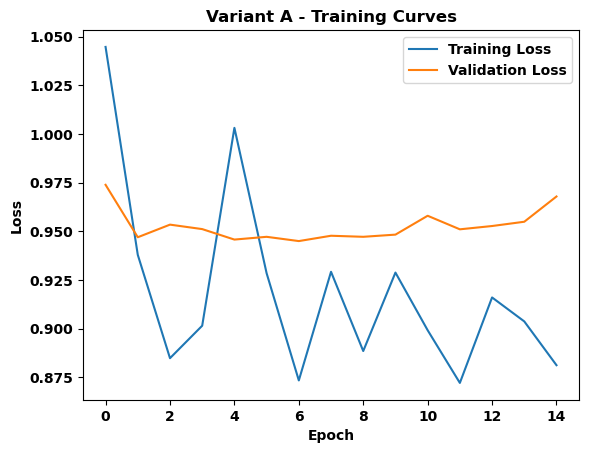

In [12]:
training_curves(train_losses_a, dev_losses_a, title="Variant A - Training Curves")

In [13]:
y_true_a, y_pred_a = predict(trained_model_a, test_loader_a)
acc_a, f1_a, pre_a = evaluate(y_pred_a, y_true_a, "Variant A - Test (plain)")


── Variant A - Test (plain) ──
Accuracy       : 0.5520
Macro-F1       : 0.2371
Macro-Precision: 0.1840

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



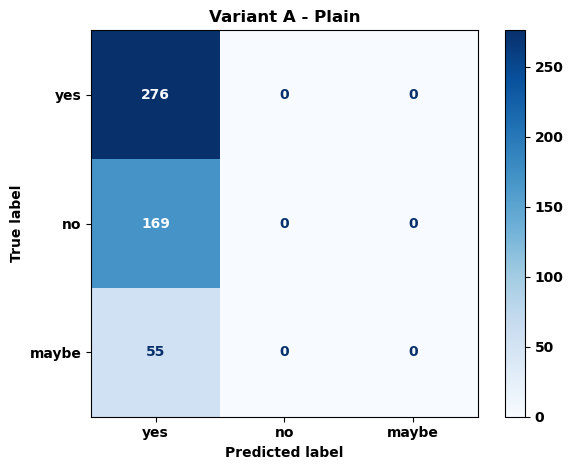

In [14]:
plot_confusion_matrix(y_true_a, y_pred_a, title="Variant A - Plain")

---
### Variant B - Question + context + MeSH (enriched representation)

In [15]:
set_all_seeds()

model_b = MLP(input_dim=128).to(DEVICE)
trained_model_b, train_losses_b, dev_losses_b = train_MLP(
    num_epochs, model_b, train_loader_b, dev_loader_b, learning_rate
)

All seeds set to 11
Epoch: 1/15 Training Loss: 1.0444 Training Accuracy: 50.0000%
Epoch: 1/15 Validation Loss: 0.9739 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9739)
Epoch: 2/15 Training Loss: 0.9387 Training Accuracy: 55.1111%
Epoch: 2/15 Validation Loss: 0.9455 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9455)
Epoch: 3/15 Training Loss: 0.8863 Training Accuracy: 55.3333%
Epoch: 3/15 Validation Loss: 0.9539 Validation Accuracy: 54.0000%
Epoch: 4/15 Training Loss: 0.9082 Training Accuracy: 55.3333%
Epoch: 4/15 Validation Loss: 0.9509 Validation Accuracy: 54.0000%
Epoch: 5/15 Training Loss: 1.0077 Training Accuracy: 54.6667%
Epoch: 5/15 Validation Loss: 0.9442 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9442)
Epoch: 6/15 Training Loss: 0.9340 Training Accuracy: 56.4444%
Epoch: 6/15 Validation Loss: 0.9487 Validation Accuracy: 54.0000%
Epoch: 7/15 Training Loss: 0.8759 Training Accuracy: 55.7778%
Epoch: 7/15 Validation L

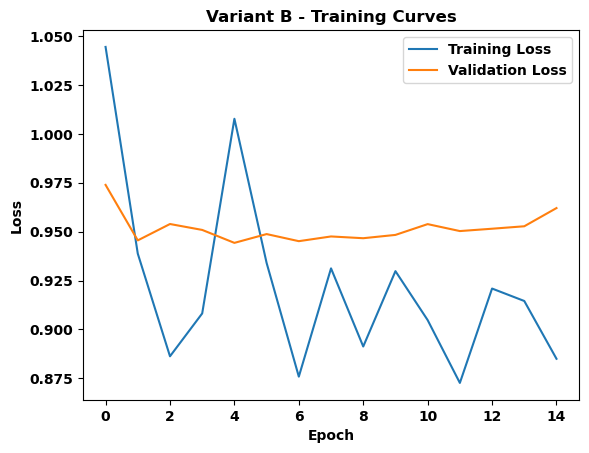

In [16]:
training_curves(train_losses_b, dev_losses_b, title="Variant B - Training Curves")

In [17]:
y_true_b, y_pred_b = predict(trained_model_b, test_loader_b)
acc_b, f1_b, pre_b = evaluate(y_pred_b, y_true_b, "Variant B - Test (+ MeSH)")


── Variant B - Test (+ MeSH) ──
Accuracy       : 0.5520
Macro-F1       : 0.2371
Macro-Precision: 0.1840

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



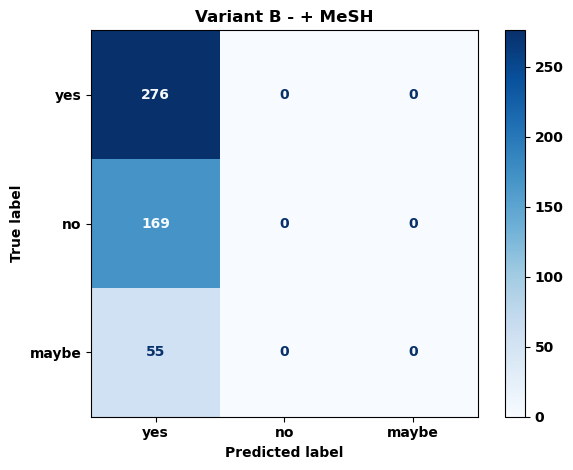

In [18]:
plot_confusion_matrix(y_true_b, y_pred_b, title="Variant B - + MeSH")

---
## Summary: Variant A vs. Variant B

In [19]:
print(f"{'Variant':<40} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 75)
for name, acc, f1, pre in [
    ("Variant A  — Plain (question + context)",  acc_a, f1_a, pre_a),
    ("Variant B  — Enriched (+ MeSH terms)",     acc_b, f1_b, pre_b),
]:
    print(f"{name:<40} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")

Variant                                    Accuracy   Macro-F1   Macro-Prec
---------------------------------------------------------------------------
Variant A  — Plain (question + context)      0.5520     0.2371       0.1840
Variant B  — Enriched (+ MeSH terms)         0.5520     0.2371       0.1840


---
## Side-by-side Confusion Matrices

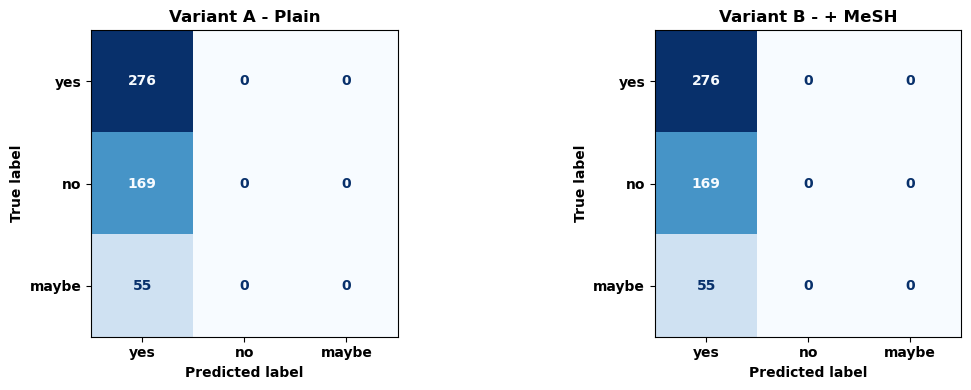

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_a, y_pred_a, "Variant A - Plain"),
    (axes[1], y_true_b, y_pred_b, "Variant B - + MeSH"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()